In [95]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit import transpile
from encode import encode_shor
from extract_syndrome import extract_syndrome
from tqdm import tqdm
import matplotlib.pyplot as plt

In [96]:
def encode_shor(qc, data):

    # Outer repetition
    qc.cx(data[0], data[3])
    qc.cx(data[0], data[6])

    # X-basis transformation
    qc.h(data[0])
    qc.h(data[3])
    qc.h(data[6])

    # Inner repetition: block 1
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])

    # Block 2
    qc.cx(data[3], data[4])
    qc.cx(data[3], data[5])

    # Block 3
    qc.cx(data[6], data[7])
    qc.cx(data[6], data[8])

In [97]:
def recover_x(qc, data, x_syn):

    # Qiskit integer values corresponding to displayed syndromes
    with qc.if_test((x_syn, 1)):
        qc.x(data[0])       # displayed 100000

    with qc.if_test((x_syn, 3)):
        qc.x(data[1])       # displayed 110000

    with qc.if_test((x_syn, 2)):
        qc.x(data[2])       # displayed 010000

    with qc.if_test((x_syn, 8)):
        qc.x(data[3])       # displayed 001000

    with qc.if_test((x_syn, 12)):
        qc.x(data[4])       # displayed 001100

    with qc.if_test((x_syn, 4)):
        qc.x(data[5])       # displayed 000100

    with qc.if_test((x_syn, 16)):
        qc.x(data[6])       # displayed 000010

    with qc.if_test((x_syn, 48)):
        qc.x(data[7])       # displayed 000011

    with qc.if_test((x_syn, 32)):
        qc.x(data[8])       # displayed 000001

In [98]:
def recover_z(qc, data, z_syn):

    # Phase error in block 1
    with qc.if_test((z_syn, 1)):
        qc.z(data[0])

    # Phase error in block 2
    with qc.if_test((z_syn, 3)):
        qc.z(data[3])

    # Phase error in block 3
    with qc.if_test((z_syn, 2)):
        qc.z(data[6])

In [99]:
def recover(qc, data, x_syn, z_syn):

    recover_x(qc, data, x_syn)
    recover_z(qc, data, z_syn)

In [100]:
def decode_shor(qc, data):

    # Undo inner repetition
    qc.cx(data[6], data[8])
    qc.cx(data[6], data[7])

    qc.cx(data[3], data[5])
    qc.cx(data[3], data[4])

    qc.cx(data[0], data[2])
    qc.cx(data[0], data[1])

    # Undo Hadamards
    qc.h(data[6])
    qc.h(data[3])
    qc.h(data[0])

    # Undo outer repetition
    qc.cx(data[0], data[6])
    qc.cx(data[0], data[3])

In [101]:
def shor_qec():

    data = QuantumRegister(9, "data")
    anc = QuantumRegister(8, "anc")

    x_syn = ClassicalRegister(6, "x_syn")
    z_syn = ClassicalRegister(2, "z_syn")

    out = ClassicalRegister(1, "out")

    qc = QuantumCircuit(data, anc, x_syn, z_syn, out)

    # -----------------
    # Prepare logical state
    # -----------------

    qc.h(data[0])          # |+> example

    # -----------------
    # Encode
    # -----------------

    encode_shor(qc, data)

    # -----------------
    # ERROR
    # -----------------
    for q in range(9):
       qc.id(data[q])
    # Example:
    #qc.y(data[6])

    # -----------------
    # Syndrome
    # -----------------

    extract_syndrome(
        qc, data, anc,
        x_syn, z_syn
    )

    # -----------------
    # Recovery
    # -----------------

    recover(qc, data, x_syn, z_syn)

    # -----------------
    # Decode
    # -----------------

    decode_shor(qc, data)

    # -----------------
    # Logical measurement
    # -----------------
    qc.h(data[0])
    qc.measure(data[0], out[0])

    return qc

In [102]:
def shor_qec_bare():

    data = QuantumRegister(9, "data")
    anc = QuantumRegister(8, "anc")

    x_syn = ClassicalRegister(6, "x_syn")
    z_syn = ClassicalRegister(2, "z_syn")

    out = ClassicalRegister(1, "out")

    qc = QuantumCircuit(data, anc, x_syn, z_syn, out)

    # -----------------
    # Prepare logical state
    # -----------------

    qc.h(data[0])          # |+> example

    # -----------------
    # Encode
    # -----------------

    encode_shor(qc, data)

    # -----------------
    # ERROR
    # -----------------
    for q in range(9):
       qc.id(data[q])
    # Example:
    #qc.y(data[6])

    # -----------------
    # Syndrome
    # -----------------

    extract_syndrome(
        qc, data, anc,
        x_syn, z_syn
    )

    # -----------------
    # Recovery
    # -----------------

    #recover(qc, data, x_syn, z_syn)

    # -----------------
    # Decode
    # -----------------

    decode_shor(qc, data)

    # -----------------
    # Logical measurement
    # -----------------
    qc.h(data[0])
    qc.measure(data[0], out[0])

    return qc

In [103]:
from qiskit_aer.noise import NoiseModel, pauli_error

def inject_noise(p):
    
   pauli = pauli_error([
      ("X", p),
      ("Y", p),
      ("Z", p),
      ("I", 1 - 3*p)
      ])

   noise_model = NoiseModel()

   noise_model.add_all_qubit_quantum_error(
      pauli,
       ["id"])
   return noise_model 

In [104]:
sim = AerSimulator(noise_model=inject_noise(0.3))

#qc = test_error("X", 2)
qc = shor_qec()
compiled = transpile(qc, sim, optimization_level=0)

result = sim.run(compiled, shots=1024).result()

counts = result.get_counts()

print(counts)

{'0 11 011100': 1, '1 00 011100': 1, '0 11 101111': 1, '0 10 101010': 1, '1 00 011110': 1, '0 01 101010': 1, '0 11 111000': 1, '0 11 000111': 1, '0 00 110111': 1, '1 10 010100': 2, '0 11 110011': 1, '1 11 101000': 2, '0 00 111110': 1, '0 10 000111': 1, '1 11 101011': 2, '0 00 001111': 1, '0 00 011011': 3, '1 01 101011': 1, '0 00 111011': 1, '1 00 111101': 1, '1 10 111001': 1, '0 00 000100': 1, '0 11 111010': 1, '0 00 101001': 2, '1 10 101000': 1, '0 11 000110': 1, '0 10 100100': 2, '0 11 010000': 4, '1 10 101011': 2, '0 00 101010': 2, '1 11 110011': 2, '0 10 000001': 1, '1 01 101110': 2, '0 01 001000': 3, '1 11 010101': 2, '1 00 001110': 1, '1 01 101111': 2, '0 11 111111': 2, '1 00 010100': 2, '0 00 010110': 1, '1 00 011111': 1, '0 01 010101': 4, '0 10 001011': 1, '0 11 011110': 1, '1 01 110001': 1, '1 10 101010': 2, '0 11 010010': 1, '1 01 111000': 4, '1 11 011111': 1, '1 00 100010': 1, '0 01 111000': 1, '0 10 110001': 1, '0 00 010101': 2, '0 11 010100': 1, '0 11 100100': 4, '1 00 111

In [105]:
print(qc.draw())

         ┌───┐          ┌───┐          ┌───┐                                   »
 data_0: ┤ H ├──■────■──┤ H ├──■────■──┤ I ├───────■───────────────────────────»
         └───┘  │    │  └───┘┌─┴─┐  │  ├───┤       │                           »
 data_1: ───────┼────┼───────┤ X ├──┼──┤ I ├───────┼──────────────■────────────»
                │    │       └───┘┌─┴─┐├───┤       │              │            »
 data_2: ───────┼────┼────────────┤ X ├┤ I ├───────┼──────────────┼────────────»
              ┌─┴─┐  │  ┌───┐     └───┘├───┤       │              │            »
 data_3: ─────┤ X ├──┼──┤ H ├──■────■──┤ I ├──■────┼──────────────┼────────────»
              └───┘  │  └───┘┌─┴─┐  │  ├───┤  │    │              │            »
 data_4: ────────────┼───────┤ X ├──┼──┤ I ├──┼────┼────■─────────┼────■───────»
                     │       └───┘┌─┴─┐├───┤  │    │    │         │    │       »
 data_5: ────────────┼────────────┤ X ├┤ I ├──┼────┼────┼─────────┼────┼───────»
                   ┌─┴─┐┌───

In [108]:

physical_error_rates = [0.01, 0.03, 0.06, 0.10, 0.14, 0.18, 0.22]

logical_error_rate = []
logical_error_rate_bare = []
for p in tqdm(physical_error_rates):

   noise_model = inject_noise(p)
   sim = AerSimulator(noise_model=noise_model)
   #qc = test_error("X", 2)
   qc = shor_qec()
   qc_bare = shor_qec_bare()
   compiled = transpile(qc, sim, optimization_level=0)
   compiled_bare = transpile(qc_bare, sim, optimization_level=0)
   result = sim.run(compiled, shots=1024).result()
   result_bare = sim.run(compiled_bare, shots=1024).result()
   counts = result.get_counts()
   counts_bare = result_bare.get_counts()
   logical_errors = 0
   logical_errors_bare = 0 
   shots = 0
   state = "0"
#print(counts)
   for bitstring, count in counts.items():

      logical = bitstring[0]      # adjust indexing as needed

      shots += count
      if state in ["1", "-"]:
        if logical != "1":
          logical_errors += count
      else:
        if logical != "0":
           logical_errors += count  

        error_rate = logical_errors / shots
   shots = 0
   for bitstring, count in counts_bare.items():

      logical = bitstring[0]      # adjust indexing as needed

      shots += count
      if state in ["1", "-"]:
        if logical != "1":
          logical_errors_bare += count
      else:
        if logical != "0":
           logical_errors_bare += count  

        error_rate_bare = logical_errors_bare / shots
   logical_error_rate_bare.append(error_rate_bare)
   logical_error_rate.append(error_rate)

100%|████████████████████████████████████████████| 7/7 [00:01<00:00,  4.87it/s]


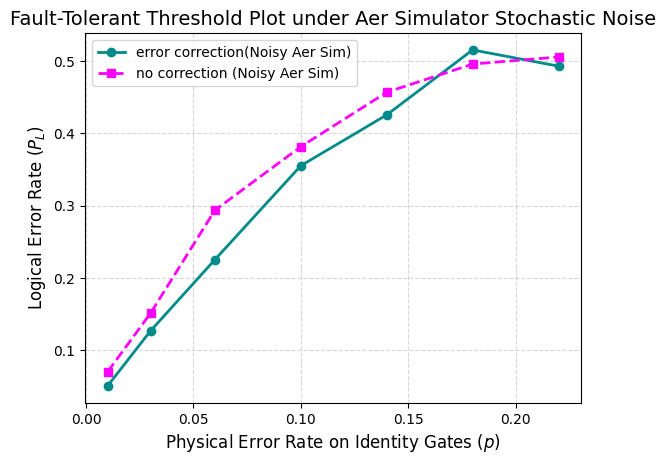

In [109]:
plt.plot(physical_error_rates, logical_error_rate, 'o-', label="error correction(Noisy Aer Sim)", linewidth=2, color='darkcyan')
plt.plot(physical_error_rates, logical_error_rate_bare, 's--', label="no correction (Noisy Aer Sim)", linewidth=2, color='magenta')


plt.xlabel("Physical Error Rate on Identity Gates ($p$)", fontsize=12)
plt.ylabel("Logical Error Rate ($P_L$)", fontsize=12)
plt.title("Fault-Tolerant Threshold Plot under Aer Simulator Stochastic Noise", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()